In [1]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version (PyTorch):", torch.version.cuda)

PyTorch version: 2.9.1+cpu
CUDA available: False


### 1. Instalación de dependencias

En esta celda se instalan todas las librerías necesarias para el desarrollo del módulo de PLN. Esto incluye:
- `transformers` y `torch` para cargar y entrenar modelos como BETO.
- `sentence-transformers` para generar embeddings semánticos con Sentence-BERT multilingüe.
- `spacy` con su modelo en español para anonimización controlada mediante reconocimiento de entidades nombradas (NER).
- `scikit-learn` para el baseline TF-IDF + SVM y métricas de evaluación.
- `fastapi` para la posterior exposición de la API REST.

> **Nota**: Esta celda solo debe ejecutarse si se trabaja en un entorno limpio (por ejemplo, Google Colab).

In [ ]:
# Solo ejecutar si es en Colab o un entorno limpio
!pip install -q \
  "transformers>=4.36.0" \
  "torch>=2.6" \
  scikit-learn pandas numpy spacy sentence-transformers \
  fastapi python-magic python-docx openpyxl \
  tqdm

In [ ]:
#la última versión de transformers (v4.37+) aún no es compatible con Keras 3, que viene por defecto en TensorFlow 2.16+.
!pip uninstall -y keras
!pip install tf-keras

### 2. Importaciones generales

Se importan las bibliotecas fundamentales que se utilizarán a lo largo del notebook:
- `pandas` y `numpy` para manipulación de datos.
- `os` y `pathlib.Path` para gestión de rutas de archivos (compatible con Windows).
- `warnings` para suprimir advertencias no críticas durante la ejecución.

Estas importaciones son esenciales para la carga, procesamiento y análisis del corpus documental.

In [2]:
import os
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings
from docx import Document  # para .docx
from transformers import pipeline, AutoTokenizer
import torch
from tqdm import tqdm
warnings.filterwarnings("ignore")

# Registrar tqdm con pandas para usar en .apply()
tqdm.pandas()

C:\Users\Rolando\entorno_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Rolando\entorno_gpu\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### 3. Definición de rutas y categorías

Se establece la ruta base del corpus (`BASE_DIR`) según la estructura real de mis archivos en Windows.  
También se define el mapeo entre los nombres de las carpetas en el sistema de archivos y las **categorías semánticas** utilizadas en el documento de tesis, tal como aparecen en la Tabla 3 (p. 55) de mi documento.

Este mapeo garantiza que cada documento se etiquete correctamente durante la carga, permitiendo una clasificación supervisada alineada con los requisitos funcionales (RF1) y los objetivos específicos de mi investigación.

In [3]:
# Ruta según mi entorno local o cambiar si se usa drive en Colab
BASE_DIR = r"E:\Documentos\proyectos\ocr\extracted_files"

CATEGORY_MAP = {
    "contratos": "Contratos",
    "correos electrónicos": "Correos electrónicos",
    "correspondencia": "Correspondencia administrativa",
    "cotizaciones": "Cotizaciones",
    "documentos fiscales": "Documentos fiscales",
    "RRHH": "Recursos Humanos"
}

### 4. Carga del corpus multiformato

Esta celda carga el corpus empresarial real desde las carpetas organizadas según las seis categorías definidas en la Tabla 3 (p. 55) de la tesis.  
Se soportan tres formatos de archivo procesables:

- **`.txt`**: archivos de texto plano (resultado de extracción previa de PDF con texto).
- **`.docx`**: documentos de Word utilizados en comunicaciones internas y formularios.
- **`.xlsx`**: hojas de cálculo con estructuras tabulares (ej. planillas de RRHH, formatos de cotización).

El script recorre cada carpeta, extrae el contenido textual manteniendo la integridad del documento, y construye un `DataFrame` unificado con columnas: `text`, `category`, y `filename`.  
Este enfoque respeta la **restricción RNF3** (solo documentos en formato de texto procesable) y garantiza que el corpus refleje fielmente el flujo documental real de la empresa guatemalteca participante.

In [4]:
def extract_text_from_docx(filepath):
    try:
        doc = Document(filepath)
        return "\n".join([para.text for para in doc.paragraphs])
    except Exception as e:
        print(f"Error al leer .docx {filepath}: {e}")
        return ""

def extract_text_from_xlsx(filepath):
    try:
        # Leer todas las hojas
        xls = pd.ExcelFile(filepath)
        all_text = []
        for sheet_name in xls.sheet_names:
            df = pd.read_excel(xls, sheet_name=sheet_name, header=None, dtype=str)
            # Rellenar NaN y unir todo
            df = df.fillna("")
            sheet_text = "\n".join(df.apply(lambda row: " ".join(row), axis=1))
            if sheet_text.strip():
                all_text.append(f"--- Hoja: {sheet_name} ---\n{sheet_text}")
        return "\n\n".join(all_text)
    except Exception as e:
        print(f"Error al leer .xlsx {filepath}: {e}")
        return ""

def load_corpus(base_dir, category_map):
    records = []
    for folder_name, label in category_map.items():
        folder_path = Path(base_dir) / folder_name
        if not folder_path.exists():
            print(f"⚠️ Carpeta no encontrada: {folder_path}")
            continue

        # .txt
        for file_path in folder_path.glob("*.txt"):
            try:
                with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                    text = f.read().strip()
                if text:
                    records.append({"text": text, "category": label, "filename": file_path.name})
            except Exception as e:
                print(f"Error al leer .txt {file_path}: {e}")

        # .docx
        for file_path in folder_path.glob("*.docx"):
            text = extract_text_from_docx(file_path)
            if text.strip():
                records.append({"text": text, "category": label, "filename": file_path.name})

        # .xlsx
        for file_path in folder_path.glob("*.xlsx"):
            text = extract_text_from_xlsx(file_path)
            if text.strip():
                records.append({"text": text, "category": label, "filename": file_path.name})

    return pd.DataFrame(records)

# Ejecutar
df = load_corpus(BASE_DIR, CATEGORY_MAP)
print(f"✅ Total de documentos cargados: {len(df)}")
print(df["category"].value_counts().sort_index())
df.to_csv("data/corpus_completo.csv", index=False, encoding="utf-8")

✅ Total de documentos cargados: 906
category
Contratos                         155
Correos electrónicos              158
Correspondencia administrativa    146
Cotizaciones                      139
Documentos fiscales               158
Recursos Humanos                  150
Name: count, dtype: int64


### 5. Anonimización híbrida del corpus (RF4)

Para cumplir con el requisito funcional **RF4** (protección de datos sensibles), se implementa una estrategia de **anonimización híbrida** que combina tres enfoques complementarios, optimizados para el dominio empresarial guatemalteco:

1. **Gazetteer personalizado basado en análisis léxico**:  
   A partir de un análisis de frecuencia con `collections.Counter`, se identificaron nombres recurrentes de personas, empresas e instituciones locales. Estas entidades se reemplazan de forma explícita *antes* de cualquier procesamiento automático, garantizando su anonimización incluso si los modelos de lenguaje las omiten.

2. **Reglas personalizadas con expresiones regulares**:  
   Se aplican patrones para proteger datos estructurados sensibles:
   - Montos en quetzales (`Q1,200.50` → `[MONTO]`)
   - NIT guatemalteco (`1234-56789-12` → `[NIT]`)
   - Teléfonos, correos electrónicos y códigos de documento.

3. **Reconocimiento de entidades nombradas (NER) con modelo especializado**:  
   Sobre el texto residual, se aplica **BETO-NER** (`mrm8488/bert-spanish-cased-finetuned-ner`), un modelo Transformer fine-tuneado en español, para detectar entidades *no incluidas en el gazetteer* (nuevos nombres de personas, empresas desconocidas, etc.).

Este flujo (gazetteer → reglas → NER) maximiza la cobertura, minimiza errores de fragmentación y preserva el contexto lingüístico necesario para el desempeño de BETO y Sentence-BERT en las tareas posteriores de clasificación y detección de duplicados. El resultado se almacena en la columna `text_anon`.

In [5]:
from transformers import pipeline, AutoTokenizer
import torch

print("Cargando modelo BETO-NER y tokenizer...")
model_name = "mrm8488/bert-spanish-cased-finetuned-ner"  # Modelo usado para BERT NER

ner_pipeline = pipeline(
    "ner",
    model=model_name,
    tokenizer=model_name,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
print("✅ Modelo y tokenizer cargados correctamente.")

Cargando modelo BETO-NER y tokenizer...



Some weights of the model checkpoint at mrm8488/bert-spanish-cased-finetuned-ner were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


✅ Modelo y tokenizer cargados correctamente.


### Definición y exploración de entidades sensibles

En esta celda se define un conjunto de **entidades sensibles conocidas** (`KNOWN_ENTITIES`) presentes en el corpus, organizadas por tipo:
- **PER**: nombres de personas,
- **ORG**: nombres de organizaciones,
- **LOC**: ubicaciones geográficas y físicas.

Este listado se utiliza como referencia para tareas de **anonimización, etiquetado o validación de entidades** durante el preprocesamiento de los documentos.

Adicionalmente, se realiza un análisis exploratorio simple sobre el texto del corpus para identificar y contar **secuencias de palabras capitalizadas** (potenciales nombres propios) utilizando expresiones regulares. El resultado muestra las 50 entidades más frecuentes, lo cual sirve para:
- detectar entidades recurrentes no incluidas aún en `KNOWN_ENTITIES`,
- refinar y ampliar manualmente el diccionario de entidades sensibles.

In [6]:
# Lista de entidades sensibles conocidas en tu corpus (empresas, personas, etc.)
KNOWN_ENTITIES = {
    "PER": [
        "Rolando Valdes", "Rolando Valdés", "Rolando Valdez", "Carlos Sandoval", "Kevin Garcia", "Sandy Ramos", "Carlos Tiniguar", "Carlos Andy", "Spencer Samayoa", "Claudia Flores", "Sergio Pineda", "Alexander Castro", "Valdéz", "Jacobo Abril Ubico",  "Jacobo, Abril Ubico",  "Abril Ubico, Jacobo", "Andrea Toc", "Jonatan Batz", "Marco Tulio Duvón", "Marco Tulio", "Erika Luis Az", "Alberta Marin", "Jose Contreras", "Erick Fernando Saravia",
        "Sandy", "Rolando", "Spencer", "Kevin", "Martín", "Claudia", "Sergio", "Carlos", "Andy", "Jonatan", "Marco", "Duvón", "Erika", "Luis", "Marin", "Andrea", "Morales", "Lopez", "Obregon", "Marroquin", "Portillo", "Mynor", "Marroquin", "Perez", "José", "Contreras", "Jose", "Evelyn", "Buch", "Mirna", "Rodriguez",
        "Geoffrey Estiven Hernández", "Martin", "Dulce Alexandra Morales", "Lesther Veliz", "Alba Leticia Marin Ramirez", "Luis Orozco", "Lilian Padilla", "Josué Saravia", "Cesar Barragan", "Ferenc Szaszdi", "Jacobo Abril", "Jacobo", "Timoteo Tiniguar",
        # Agrega cualquier otro nombre recurrente que identifiques
    ],
    "ORG": [
        "Liberty Networks", "Corporación Guatetalents", "Corporacion Guatetalents", "TIGO", "SAT", "Cable & Wireless", "Tigo Business", "COLUMBUS NETWORKS", "Liberty Latin America", "INTEGRACION DE INFORMACION, S.A.", "Terguatemala", "Colegio BM-PC", "Accesorios Globales",
        "CELTECH", "C&W", "Intelaf", "Intcomex", "Guatetalents", "MegaPrint", "TIGO", "Comcel", "Comunicaciones Celulares", "Guatex", "Comunicaciones Celulares, Sociedad Anónima", "Tigo Business",
        "Liberty", "COLUMBUS", "cwcbusiness.com", "IntegraSAP", "SAP AG",
        "Superintendencia de Administración Tributaria", "Superintendencia de Administracion Tributaria"
    ],
    "LOC": [
        "Guatemala", "Zacapa", "Jutiapa", "Escuintla", "Esquipulas", "Ciudad de Guatemala",
        "Poptun", "Santa Elena", "Sayaxche", "Barberena", "Izabal", "Santa Rosa", "Petén",
        "Edificio Buró", "Plaza Buró", "Europlaza", "Oficina 1701", "Zona 10", 
    ]
}

from collections import Counter
import re
words = [w for w in re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\b', ' '.join(df["text"])) if len(w.split()) <= 2]
Counter(words).most_common(50)

[('Sujeto', 11255),
 ('Contribuyente', 8163),
 ('Guatemala', 1424),
 ('Cliente', 1083),
 ('El', 1036),
 ('Servicio', 1025),
 ('En', 1024),
 ('Comcel', 1013),
 ('Charges', 937),
 ('Servicios', 898),
 ('Fecha', 680),
 ('Para', 608),
 ('Reconozco', 604),
 ('De', 602),
 ('Sociedad Anonima', 595),
 ('Se', 589),
 ('La', 549),
 ('Comunicaciones Celulares', 540),
 ('Nombre', 520),
 ('Inc', 488),
 ('No', 470),
 ('Recargas', 469),
 ('Numero', 452),
 ('Sociedad', 441),
 ('Service', 436),
 ('Orden', 427),
 ('Business', 420),
 ('Si', 398),
 ('Los', 392),
 ('Departamento', 387),
 ('Codigo', 382),
 ('Identificacion', 374),
 ('Monto', 361),
 ('Una', 359),
 ('Facturacion', 356),
 ('This', 345),
 ('Periodo', 341),
 ('Circuito', 317),
 ('Internet', 295),
 ('Ciudad', 282),
 ('Celtech', 276),
 ('Estimated', 271),
 ('Total', 260),
 ('El Cliente', 253),
 ('Nivel', 253),
 ('Pagina', 250),
 ('Related', 249),
 ('Bills', 249),
 ('Please', 249),
 ('Canadian', 249)]

## 🧹 Pre-procesamiento: Anonimización por Reglas

Antes de pasar el texto al modelo de Deep Learning (BETO), aplicamos una función determinista `anonymize_with_rules` para sanear datos sensibles que siguen un formato estricto.

| Patrón Detectado | Ejemplo Real | Reemplazo |
| :--- | :--- | :--- |
| **Moneda (GT)** | `Q. 4,500.50` | `[MONTO]` |
| **Códigos/Facturas** | `CA5542-403` | `[CODIGO]` |
| **NIT** | `1234-5678-9` | `[NIT]` |
| **Teléfonos** | `+502 5555-5555` | `[TELEFONO]` |
| **Correos Electrónicos** | `usuario@mail.com` | `[CORREO]` |
| **Sitios Web / URLs** | `www.empresa.com.gt` | `[SITIO_WEB]` |

Esta estrategia híbrida (Reglas + IA) asegura que los datos numéricos y estructurados sean anonimizados con **100% de precisión** sin depender de la predicción probabilística del modelo.

In [7]:
import re

def anonymize_with_rules(text):

    # 1. URLs
    text = re.sub(
        r'\b(?:https?://|www\.)[^\s]+\b',
        '[SITIO_WEB]',
        text,
        flags=re.IGNORECASE
    )

    # Correos entre <>
    text = re.sub(
        r'<\s*[A-Za-z0-9._%+-]+@(?![EMPRESA])([A-Za-z0-9.-]+\.[A-Za-z]{2,})\s*>',
        '<[CORREO]>',
        text
    )

    # Correos normales
    text = re.sub(
        r'[A-Za-z0-9._%+-]+@(?![EMPRESA])([A-Za-z0-9.-]+\.[A-Za-z]{2,})',
        '[CORREO]',
        text
    )

    # 3. Direcciones (tolerante, Guatemala + OCR)
    text = re.sub(
        r'\b(?:'
            r'\d{1,2}\s*(?:[Aa]|\d{1,2}[aA])?\s*'                    # 6a, 6 A, 10
            r'(?:Calle|Cal(le)?|Avenida|Av\.?|Ave\.?|Aven(?:ida)?|'
            r'Calzada|Calz\.?|Blvd\.?|Boulevard|Boulevar|'
            r'Carretera|Carr\.?|Ruta|Km\.?)'
            r'[\s,]+'
            r'[A-Za-z0-9#.\-“”"\-\/\s]+?'                            # nombre / número
        r'|'
            r'(?:Zona|Z0na)\s*\d{1,2}'                               # Zona 1, Z0na 10
        r'|'
            r'Km\.?\s*\d+(?:\.\d+)?'                                 # Km 14.5
        r')'
        r'(?:[\s,]+(?:'
            r'Zona|Z0na|Col\.?|Colonia|Residenciales?|'
            r'Edificio|Torre|Oficina|Apto\.?|Apartamento|'
            r'Casa|Nivel|Piso'
        r')[\s#]*\w+)*',
        '[DIRECCION]',
        text,
        flags=re.IGNORECASE
    )

    # 4. DPI
    text = re.sub(
        r'\b\d{4}(?:[-\s]?\d{5})(?:[-\s]?\d{4})\b',
        '[DPI]',
        text
    )

    # 5. NIT (formatos guatemaltecos comunes)
    text = re.sub(
        r'(NIT\.?\s*:?\s*)\d{6,9}(?:[-\s]?[0-9Kk])?',
        r'\1[NIT]',
        text,
        flags=re.IGNORECASE
    )
    
    # 6. Teléfonos Guatemala (####-#### | #### #### | con código país)
    text = re.sub(
        r'\b(?:\+?502[\s-]?)?[2456]\d{3}[\s-]\d{4}\b',
        '[TELEFONO]',
        text
    )

    # 7. Montos (actualización para manejar más formatos)
    text = re.sub(
        r'\b(?:[QUS]\.?[\s]?\$?[\s]?[A-Za-z0-9.,]+(?:\s?[\d,]*\.\d{1,2})?|S\$\s?\d+(?:[\s,]?\d{3})*(?:\.\d{1,2})?|¥\s?\d+(?:[\s,]?\d{3})*(?:\.\d{1,2})?)\b',
        '[MONTO]',
        text
    )

    # 8. Códigos
    text = re.sub(
        r'\b[A-Z]{2,4}\d{2,4}-?\d{4,10}\b',
        '[CODIGO]',
        text
    )

    # 9. Fechas (formatos múltiples + tolerancia OCR + "de" opcional)
    text = re.sub(
        r'\b('
        r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}'                      # 14/02/2024 | 1-6-20
        r'|\d{4}[/-]\d{1,2}[/-]\d{1,2}'                       # 2024-02-14
        r'|\d{1,2}\s*(?:de\s*)?(?:'
            r'ene(?:ro)?|feb(?:rero)?|mar(?:zo)?|abr(?:il)?|'
            r'may(?:o)?|jun(?:io)?|jul(?:io)?|ago(?:sto)?|'
            r'sep(?:tiembre)?|set(?:iembre)?|oct(?:ubre)?|'
            r'nov(?:iembre)?|dic(?:iembre)?'
        r')\s*(?:de\s*)?\d{2,4}'                              # 12 agosto 2020 | 12 de agosto 2020 | 12 agosto de 2020
        r'|\d{1,2}[A-Z]{3}\s*\d{4}'                            # 04MAY 1986
        r')'
        r'(?:\s+\d{1,2}:\d{2}(?::\d{2})?\s*(?:AM|PM)?)?'      # hora opcional
        r'\b',
        '[FECHA]',
        text,
        flags=re.IGNORECASE
    )


    return text

## Núcleo de Procesamiento: Aplicación de NER y Reemplazo

La función `_apply_ner_replacement` es el motor de inferencia del script. Recibe un fragmento de texto limpio y coordina la detección de entidades con el modelo **BETO** para realizar la sustitución de datos sensibles.

### Mapeo de Entidades (Entity Mapping)

El modelo clasifica las palabras en grupos (`entity_group`). Esta función estandariza esas clasificaciones en etiquetas de anonimización genéricas:

| Etiqueta del Modelo (BETO) | Significado | Reemplazo Generado |
| :--- | :--- | :--- |
| **PER** | Personas | `[PERSONA]` |
| **ORG** | Organizaciones | `[EMPRESA]` |
| **LOC** | Lugares / Ubicaciones | `[LUGAR]` |
| **MISC** | Eventos, Nacionalidades... | `[LUGAR]` |

### Lógica Crítica: Iteración Inversa

Una particularidad técnica importante de esta función es cómo realiza los reemplazos en el texto (`reversed(entities)`):

> **¿Por qué itero al revés?**
>
> Si reemplazo una palabra al inicio del texto (ej. "Juan" $\rightarrow$ "[PERSONA]"), la longitud total del texto cambia. Esto haría que los índices (`start`, `end`) de las entidades siguientes queden desfasados, provocando errores o cortes de texto incorrectos.
>
> **Solución:** Al reemplazar **desde el final hacia el principio**, los cambios de longitud no afectan a los índices de las entidades que están antes. Esto garantiza una reconstrucción perfecta del texto.

In [8]:
def _apply_ner_replacement(text_fragment):
    """
    Función auxiliar que recibe un fragmento de texto, aplica NER 
    y realiza los reemplazos de atrás hacia adelante.
    """
    try:
        # El pipeline gestiona sus propios tokens especiales internamente
        entities = ner_pipeline(text_fragment)
        
        # Iteramos en reverso para que reemplazar no afecte los índices de inicio de las siguientes entidades
        for ent in reversed(entities):
            start = ent["start"]
            end = ent["end"]
            group = ent["entity_group"]
            
            replacement = None
            if group == "PER":
                replacement = "[PERSONA]"
            elif group == "ORG":
                replacement = "[EMPRESA]"
            elif group in ["LOC", "MISC"]:
                replacement = "[LUGAR]"
            
            if replacement:
                text_fragment = text_fragment[:start] + replacement + text_fragment[end:]
                
    except Exception as e:
        print(f"Error procesando fragmento NER: {e}")
        pass
        
    return text_fragment

### Anonimización híbrida con manejo de textos largos
Esta función anonimiza el texto en tres pasos:
- Primero, reemplaza nombres, empresas y lugares conocidos (como SAT o Guatemala) usando una lista personalizada (gazetteer).
- Luego, aplica reglas para ocultar datos como montos (Q1,200 → [MONTO]), NIT, correos y teléfonos.
- Finalmente, usa el modelo BETO-NER para detectar cualquier otra entidad sensible que no esté en la lista.
Para documentos muy largos (más de 500 tokens), el texto se divide en fragmentos, se procesa cada uno por separado y luego se vuelve a unir. Así, garantizamos que todo el documento sea revisado, sin importar su longitud.

In [9]:
def anonymize_text(text):
    # Paso 1: Aplicar gazetteer al texto COMPLETO (Igual que antes)
    entity_map = {"PER": "[PERSONA]", "ORG": "[EMPRESA]", "LOC": "[LUGAR]"}
    # Asumo que KNOWN_ENTITIES está definido globalmente
    for label, items in KNOWN_ENTITIES.items():
        if label not in entity_map:
            continue
        replacement = entity_map[label]
        for item in items:
            pattern = r'\b' + re.escape(item) + r'\b'
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    # Paso 2: Aplicar reglas al texto COMPLETO (Igual que antes)
    text = anonymize_with_rules(text)
    
    # Paso 3: BETO-NER con Ventana Deslizante (Chunking)
    
    # Tokenizamos TODO el texto sin agregar tokens especiales ([CLS], [SEP]) 
    # para tener los IDs puros y poder dividirlos nosotros.
    all_tokens = tokenizer.encode(text, add_special_tokens=False)
    
    # Si cabe en una sola pasada, lo hacemos directo
    if len(all_tokens) < 500:
        text = _apply_ner_replacement(text)
    else:
        # Si es largo, dividimos, procesamos y reconstruimos
        processed_fragments = []
        
        # Usamos 500 en lugar de 512 para dejar margen de seguridad 
        # (el pipeline agregará [CLS] y [SEP] automáticamente a cada fragmento)
        window_size = 500
        
        for i in range(0, len(all_tokens), window_size):
            # 1. Cortamos un bloque de tokens
            chunk_ids = all_tokens[i : i + window_size]
            
            # 2. Decodificamos el bloque de vuelta a texto limpio
            chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True)
            
            # 3. Aplicamos NER y reemplazo SOLO a este bloque
            processed_chunk = _apply_ner_replacement(chunk_text)
            
            processed_fragments.append(processed_chunk)
        
        # 4. Unimos los fragmentos procesados
        # Nota: tokenizer.decode puede perder espacios exactos, 
        # por lo que unimos con un espacio para asegurar separación.
        text = " ".join(processed_fragments)

    return text

### Integración de la estrategia de anonimización

La función `anonymize_text` implementa la estrategia híbrida descrita, aplicando los componentes en un orden cuidadosamente definido para maximizar la cobertura y minimizar interferencias:

1. **Primero se aplica el gazetteer personalizado**, reemplazando de forma explícita las entidades conocidas del contexto guatemalteco (como `CELTECH`, `Comcel`, `SAT`, nombres de personas y municipios). Esto evita que el modelo de NER intente procesar nombres comerciales, siglas o apellidos que podrían fragmentarse o interpretarse incorrectamente.

2. **Luego se aplican las reglas personalizadas** (`anonymize_with_rules`), que anonimizan patrones estructurados como montos en quetzales, NIT, teléfonos y correos electrónicos, independientemente del contexto lingüístico.

3. **Finalmente, se ejecuta el NER con BETO-NER** sobre el texto residual, permitiendo detectar entidades sensibles que *no fueron incluidas en el gazetteer* (por ejemplo, nuevos empleados, proveedores no anticipados o instituciones no listadas).

Este flujo garantiza que **todos los datos sensibles conocidos sean eliminados de forma robusta**, mientras se **preserva el contexto textual necesario** para el desempeño de los modelos de PLN posteriores (BETO y Sentence-BERT). La función se aplica a todo el corpus antes de la partición y el modelado.

In [10]:
# Aplicar al corpus completo
df["text_anon"] = df["text"].progress_apply(anonymize_text)

# Guardar
df.to_csv("data/corpus_anon.csv", index=False, encoding="utf-8")
print("✅ Anonimización completada. Ejemplo:")
print(df["text_anon"].iloc[0][:500] + "...")

100%|████████████████████████████████████████████████████████████████████████████████| 906/906 [50:38<00:00,  3.35s/it]


✅ Anonimización completada. Ejemplo:
[EMPRESA] CONTRATO MAESTRO PRESTACION DE [PERSONA]TO DE TELECOMUNICACIONES Y O TECNOLOGIAS DE LA INFORMACION Entre, EMPRESA DE [LUGAR][LUGAR]R, LIMITADA ( en adelante [EMPRESA] ), constituida legalmente bajo las leyes de la [EMPRESA]a de [LUGAR]R y domiciliada en [LUGAR][LUGAR][LUGAR], identificada con el [LUGAR] ( [LUGAR] ) numero 2105941 - 1 representada en este acto por [PERSONA], mayor de edad, casado, [LUGAR], salvadorefo y con domicilio en la [LUGAR] y de transito en esta ciudad para la fi...


### 6. Partición estratificada del corpus (80% entrenamiento, 10% validación, 10% prueba)

Se divide el corpus anonimizado en tres conjuntos:
- **Entrenamiento (80%)**: para ajustar los parámetros del modelo.
- **Validación (10%)**: para monitorear el desempeño durante el entrenamiento y evitar sobreajuste (early stopping).
- **Prueba (10%)**: para evaluar el desempeño final de forma imparcial.

La partición se realiza de forma **estratificada** por categoría, garantizando que todas las clases estén representadas proporcionalmente en cada subconjunto. Esto es especialmente importante dado el ligero desbalance en el corpus (Tabla 3, p. 55) y permite una evaluación justa mediante métricas macro (RNF2).

In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.10, stratify=df["category"], random_state=42
)
train_df, val_df = train_test_split(
    train_df, test_size=0.111, stratify=train_df["category"], random_state=42
)

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 724, Val: 91, Test: 91


### 7. Baseline: TF-IDF + SVM

Se implementa un modelo clásico de clasificación como **punto de comparación** (requisito no funcional RNF5).  
El pipeline combina:
- **TF-IDF** con un vocabulario de hasta 10,000 términos y n-gramas (1-2).
- **SVM con kernel lineal**, un clasificador robusto para textos de alta dimensionalidad.

Este enfoque representa el estado del arte previo a los modelos Transformer y servirá para cuantificar la mejora aportada por BETO. Se evalúa en el mismo conjunto de prueba y con las mismas métricas (F1 macro) que el modelo propuesto, asegurando una comparación rigurosa.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score

X_train = train_df["text_anon"]
y_train = train_df["category"]
X_test = test_df["text_anon"]
y_test = test_df["category"]

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("clf", SVC(kernel="linear", random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("=== TF-IDF + SVM (Baseline) ===")
print(classification_report(y_test, y_pred, digits=4))
baseline_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1: {baseline_f1:.4f}")

=== TF-IDF + SVM (Baseline) ===
                                precision    recall  f1-score   support

                     Contratos     1.0000    1.0000    1.0000        15
          Correos electrónicos     1.0000    0.9375    0.9677        16
Correspondencia administrativa     0.8750    0.9333    0.9032        15
                  Cotizaciones     0.8667    0.9286    0.8966        14
           Documentos fiscales     1.0000    1.0000    1.0000        16
              Recursos Humanos     1.0000    0.9333    0.9655        15

                      accuracy                         0.9560        91
                     macro avg     0.9569    0.9555    0.9555        91
                  weighted avg     0.9589    0.9560    0.9568        91

Macro F1: 0.9555


### Evaluación del modelo mediante matriz de confusión normalizada

En esta celda se calcula y visualiza la **matriz de confusión normalizada** del modelo de clasificación (TF-IDF + SVM) utilizando el conjunto de prueba.  
La normalización por fila permite interpretar cada valor como la **proporción de predicciones correctas e incorrectas por clase real**, facilitando la comparación del desempeño entre categorías.

La matriz se presenta como un **mapa de calor**, donde:
- las filas representan las etiquetas reales,
- las columnas representan las etiquetas predichas,
- los valores indican la tasa de acierto o confusión entre clases.

Esta visualización permite identificar **clases bien diferenciadas**, así como **patrones de confusión** que pueden orientar ajustes futuros del modelo.


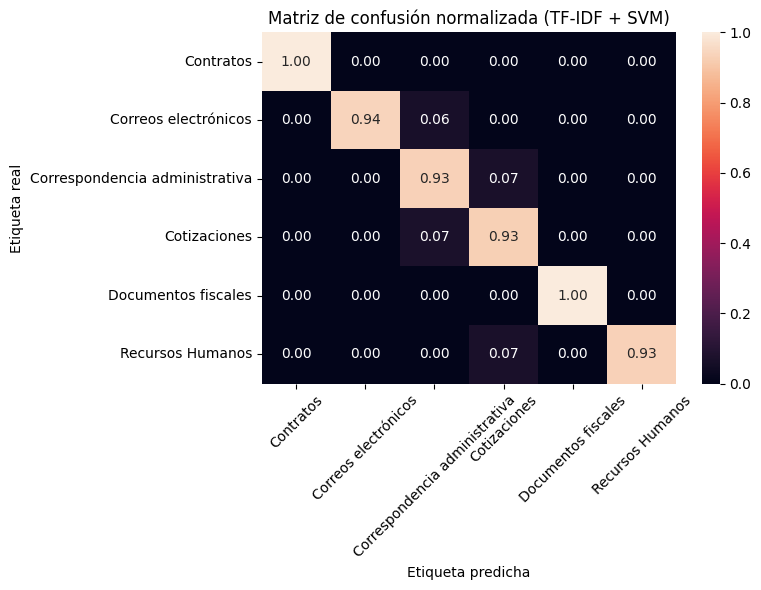

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predicciones (ya las tienes)
# y_pred = pipeline.predict(X_test)

# Matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')

# Obtener las etiquetas únicas
labels = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels)
plt.title("Matriz de confusión normalizada (TF-IDF + SVM)")
plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 8. Fine-tuning de BETO para clasificación automática

Se adapta el modelo **BETO** (Cañete et al., 2020) al dominio empresarial guatemalteco mediante *transfer learning*.  
El proceso incluye:
- Codificación de etiquetas categóricas.
- Preparación de datasets personalizados para `Trainer` de Hugging Face.
- Configuración de hiperparámetros alineados con tu metodología (p. 68): tasa de aprendizaje = 2e-5, batch size = 16, hasta 5 épocas.
- Evaluación con métrica **macro F1**, según el requisito RNF2.

Este modelo representa la propuesta principal para la clasificación (RF1) y busca superar significativamente al baseline, demostrando la viabilidad del PLN moderno en contextos locales.

In [ ]:
# Instalar/actualizar accelerate a una versión compatible
!pip install "transformers>=4.36.0" "accelerate>=0.26.0" torch evaluate

## Preparación de etiquetas para clasificación supervisada

En esta etapa se realiza la codificación de las etiquetas categóricas del corpus documental con el objetivo de utilizarlas en el entrenamiento supervisado del modelo BETO.

Se emplea `LabelEncoder` para transformar las categorías textuales en valores numéricos consecutivos, garantizando consistencia entre los conjuntos de entrenamiento, validación y prueba.

Adicionalmente, se construyen los diccionarios `label2id` e `id2label`, los cuales permiten:
- Asociar cada clase textual con su identificador numérico
- Facilitar la interpretación de las predicciones del modelo
- Persistir correctamente la metadata de clasificación junto con el modelo entrenado

Este paso es fundamental para asegurar la trazabilidad entre las etiquetas originales del dominio y las salidas generadas por el modelo de lenguaje.


In [14]:
from sklearn.preprocessing import LabelEncoder

# ===============================
# Preparación de etiquetas
# ===============================
le = LabelEncoder()

train_df["label"] = le.fit_transform(train_df["category"])
val_df["label"] = le.transform(val_df["category"])
test_df["label"] = le.transform(test_df["category"])

label2id = {label: idx for idx, label in enumerate(le.classes_)}
id2label = {idx: label for label, idx in label2id.items()}

print("Clases detectadas:")
print(label2id)

Clases detectadas:
{'Contratos': 0, 'Correos electrónicos': 1, 'Correspondencia administrativa': 2, 'Cotizaciones': 3, 'Documentos fiscales': 4, 'Recursos Humanos': 5}


## Definición del dataset personalizado para BETO

En esta sección se define una clase `Dataset` personalizada compatible con PyTorch, encargada de preparar los datos de entrada para el modelo BETO.

La clase encapsula las siguientes responsabilidades:
- Tokenizar los textos utilizando el tokenizador de BETO
- Aplicar truncamiento y padding a una longitud máxima fija
- Construir las máscaras de atención necesarias para el modelo Transformer
- Asociar cada texto con su etiqueta numérica correspondiente

Este diseño permite desacoplar la lógica de preprocesamiento del entrenamiento del modelo, facilitando la reutilización del dataset en las fases de entrenamiento, validación y prueba.

La estructura retornada por el dataset es compatible con la interfaz esperada por la clase `Trainer` de HuggingFace.


In [15]:
import torch
from torch.utils.data import Dataset

# ===============================
# Dataset personalizado BETO
# ===============================
class DocDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

## Carga del modelo BETO y construcción de conjuntos de datos

En esta etapa se carga el modelo BETO base (`dccuchile/bert-base-spanish-wwm-cased`) junto con su tokenizador correspondiente, configurándolo para una tarea de clasificación supervisada multiclase.

El modelo se inicializa especificando:
- El número total de clases del problema
- Los mapeos entre identificadores numéricos y etiquetas textuales (`id2label` y `label2id`)

Posteriormente, se instancian los conjuntos de datos de entrenamiento, validación y prueba utilizando el dataset personalizado definido previamente. Cada conjunto contiene los textos anonimizados y las etiquetas codificadas correspondientes.

Esta separación explícita de los conjuntos de datos permite evaluar el desempeño del modelo de forma objetiva y evita fugas de información entre las distintas fases del proceso de aprendizaje.


In [16]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ===============================
# Cargar BETO (modelo + tokenizer)
# ===============================
beto_model_name = "dccuchile/bert-base-spanish-wwm-cased"

beto_tokenizer = AutoTokenizer.from_pretrained(beto_model_name)
beto_model = AutoModelForSequenceClassification.from_pretrained(
    beto_model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# ===============================
# Crear datasets
# ===============================
train_dataset = DocDataset(
    train_df["text_anon"].tolist(),
    train_df["label"].tolist(),
    beto_tokenizer
)

val_dataset = DocDataset(
    val_df["text_anon"].tolist(),
    val_df["label"].tolist(),
    beto_tokenizer
)

test_dataset = DocDataset(
    test_df["text_anon"].tolist(),
    test_df["label"].tolist(),
    beto_tokenizer
)

print("BETO cargado y datasets creados correctamente")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BETO cargado y datasets creados correctamente


In [17]:
import numpy as np
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return {"macro_f1": f1_score(labels, preds, average="macro")}

training_args = TrainingArguments(
    output_dir="beto_finetuned",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    seed=42,
    logging_dir="logs",
    report_to="none"    
)

trainer_beto = Trainer(
    model=beto_model,
    args=training_args,    
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=beto_tokenizer,
    compute_metrics=compute_metrics
)

trainer_beto.train()

# Evaluación final
results = trainer_beto.evaluate(test_dataset)
print(f"\n=== BETO Fine-tuned ===\nMacro F1 en prueba: {results['eval_macro_f1']:.4f}")

Epoch,Training Loss,Validation Loss,Macro F1
1,No log,1.400488,0.595403
2,No log,0.682737,0.794794
3,No log,0.314142,0.931637
4,No log,0.180464,0.931986
5,No log,0.099004,0.966590



=== BETO Fine-tuned ===
Macro F1 en prueba: 0.9892


In [18]:
# ===============================
# Guardar modelo BETO fine-tuned
# ===============================

from transformers import BertForSequenceClassification, BertTokenizer

output_dir_beto = "./models/modelo_beto_finetuned_v1"

# Verificación fuerte: debe ser BERT para clasificación
assert isinstance(beto_model, BertForSequenceClassification), \
    "❌ El modelo NO es BertForSequenceClassification (BETO)"

# Guardar modelo y tokenizer
beto_model.save_pretrained(output_dir_beto)
beto_tokenizer.save_pretrained(output_dir_beto)

print(f"✅ Modelo BETO guardado en: {output_dir_beto}")
print("✅ Incluye pesos, config y tokenizer")

✅ Modelo BETO guardado en: ./models/modelo_beto_finetuned_v1
✅ Incluye pesos, config y tokenizer


In [ ]:
Para cargarlo después (inferencia):from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained(output_dir_beto)
tokenizer = AutoTokenizer.from_pretrained(output_dir_beto)

Generando predicciones con BETO fine-tuned...


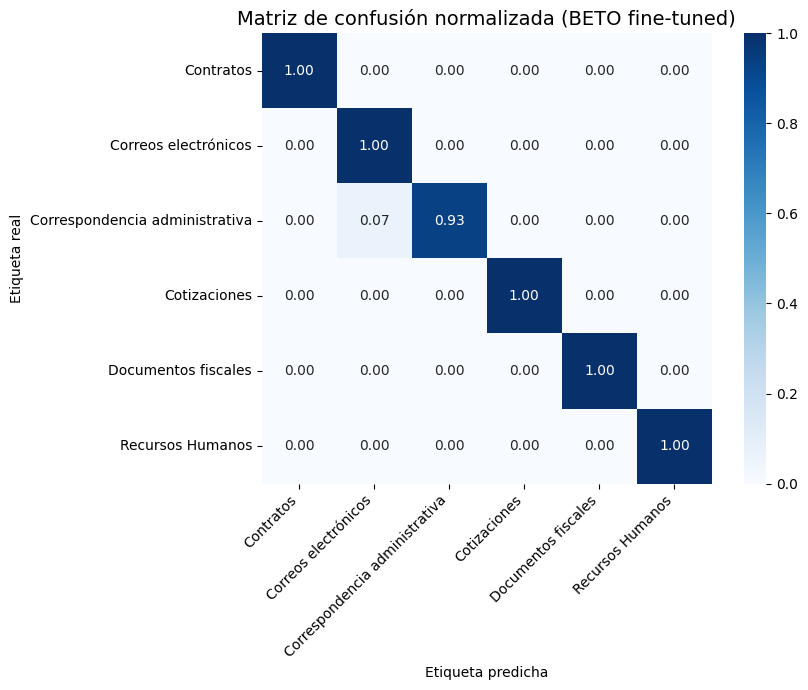


=== Reporte de clasificación (BETO) ===
                                precision    recall  f1-score   support

                     Contratos     1.0000    1.0000    1.0000        15
          Correos electrónicos     0.9412    1.0000    0.9697        16
Correspondencia administrativa     1.0000    0.9333    0.9655        15
                  Cotizaciones     1.0000    1.0000    1.0000        14
           Documentos fiscales     1.0000    1.0000    1.0000        16
              Recursos Humanos     1.0000    1.0000    1.0000        15

                      accuracy                         0.9890        91
                     macro avg     0.9902    0.9889    0.9892        91
                  weighted avg     0.9897    0.9890    0.9890        91



In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener predicciones en el conjunto de prueba
print("Generando predicciones con BETO fine-tuned...")
predictions = trainer_beto.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# 2. Decodificar etiquetas (opcional, para mostrar nombres reales)
label_names = le.classes_  # asumiendo que 'le' es tu LabelEncoder

# 3. Calcular matriz de confusión normalizada
cm = confusion_matrix(labels, preds, normalize='true')  # normalizada por filas (recall)

# 4. Visualizar
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='Blues',
    square=True
)
plt.title("Matriz de confusión normalizada (BETO fine-tuned)", fontsize=14)
plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Mostrar reporte de clasificación (opcional)
print("\n=== Reporte de clasificación (BETO) ===")
print(classification_report(labels, preds, target_names=label_names, digits=4))

In [21]:
import pandas as pd
import numpy as np

# 1. Predicciones de BETO
print("Generando predicciones de BETO...")
beto_predictions = trainer_beto.predict(test_dataset)
beto_preds = np.argmax(beto_predictions.predictions, axis=1)

# 2. Predicciones de TF-IDF + SVM (asumiendo que ya tienes el pipeline entrenado: 'tfidf_svm_pipeline')
print("Generando predicciones de TF-IDF + SVM...")
tfidf_preds = pipeline.predict(test_df["text_anon"])

# 3. Etiquetas reales (del test_df)
true_labels = test_df["category"].values  # asumiendo que la columna se llama "category"

# 4. Asegurar alineación de índices
test_df_reset = test_df.reset_index(drop=True)

# 5. Crear DataFrame comparativo
comparison_df = test_df_reset.copy()
comparison_df["true_label"] = true_labels
comparison_df["beto_pred"] = le.inverse_transform(beto_preds)  # Nombres reales
comparison_df["tfidf_pred"] = tfidf_preds  # Asume que el pipeline devuelve etiquetas string
comparison_df["beto_correct"] = (beto_preds == le.transform(true_labels))
comparison_df["tfidf_correct"] = (tfidf_preds == true_labels)

# 6. Filtrar documentos donde al menos un modelo falla
errors_df = comparison_df[
    (~comparison_df["beto_correct"]) | (~comparison_df["tfidf_correct"])
].copy()

# 7. Guardar para revisión manual
errors_df.to_csv("results/model_comparison_errors.csv", index=False, encoding="utf-8")

print(f"🔍 Se encontraron {len(errors_df)} documentos con al menos un error.")
print(f"   - BETO erró en {(~errors_df['beto_correct']).sum()} documentos.")
print(f"   - TF-IDF erró en {(~errors_df['tfidf_correct']).sum()} documentos.")
print("📄 Archivo guardado en: results/model_comparison_errors.csv")

Generando predicciones de BETO...


Generando predicciones de TF-IDF + SVM...
🔍 Se encontraron 5 documentos con al menos un error.
   - BETO erró en 1 documentos.
   - TF-IDF erró en 4 documentos.
📄 Archivo guardado en: results/model_comparison_errors.csv


### 9. Detección de duplicados

### Baseline para detección de duplicados (RF5)

Como método de comparación para la detección de documentos duplicados o muy similares, se implementa un baseline basado en **TF-IDF y similitud coseno**. Este enfoque representa el estado del arte en métodos no semánticos y permite evaluar si el uso de embeddings contextuales (Sentence-BERT) aporta una mejora significativa en la identificación de similitud más allá de la coincidencia léxica.

- **Vectorización**: TF-IDF con unigramas y bigramas, usando el texto anonimizado (`text_anon`).
- **Umbral**: Se consideran "duplicados" los pares con similitud ≥ 0.85 (ajustado empíricamente).
- **Salida**: Lista de pares de documentos candidatos a ser duplicados.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# 1. Vectorización TF-IDF del corpus anonimizado
print("Generando vectores TF-IDF para detección de duplicados...")
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words=None,  # mantén todo, ya está anonimizado
    lowercase=True
)
tfidf_matrix = vectorizer.fit_transform(df["text_anon"])

# 2. Calcular matriz de similitud coseno (solo triángulo superior para evitar duplicados)
print("Calculando matriz de similitud coseno...")
similarity_matrix = cosine_similarity(tfidf_matrix)

# 3. Definir umbral de duplicado (se ha ajustado empíricamente)
UMBRAL_DUPLICADO = 0.85

# 4. Encontrar pares duplicados DENTRO DE LA MISMA CATEGORÍA
duplicados = []
n = len(df)

for i in range(n):
    for j in range(i + 1, n):
        # ✅ Solo comparar si son de la misma categoría
        if df.iloc[i]["category"] == df.iloc[j]["category"]:
            if similarity_matrix[i, j] >= UMBRAL_DUPLICADO:
                duplicados.append({
                    "doc_id_1": df.index[i],
                    "doc_id_2": df.index[j],
                    "filename_1": df.iloc[i]["filename"],
                    "filename_2": df.iloc[j]["filename"],
                    "category_1": df.iloc[i]["category"],
                    "category_2": df.iloc[j]["category"],
                    "similarity": similarity_matrix[i, j]
                })

# 5. Guardar con nombres consistentes con SBERT
duplicados_df = pd.DataFrame(duplicados)
duplicados_df.rename(columns={
    "filename_1": "doc1",
    "filename_2": "doc2",
    "category_1": "category"
}, inplace=True)
duplicados_df = duplicados_df[["doc1", "doc2", "similarity", "category"]]  # solo columnas necesarias
duplicados_df.to_csv("results/duplicados_tfidf.csv", index=False)

print(f"\n Baseline (TF-IDF): Se encontraron {len(duplicados_df)} pares duplicados (umbral ≥ {UMBRAL_DUPLICADO}).")

Generando vectores TF-IDF para detección de duplicados...
Calculando matriz de similitud coseno...

 Baseline (TF-IDF): Se encontraron 5258 pares duplicados (umbral ≥ 0.85).


### Detección de duplicados mediante Sentence-BERT multilingüe

Para cumplir con el requisito funcional **RF5**, se utiliza el modelo **`paraphrase-multilingual-mpnet-base-v2`**, un Sentence-BERT multilingüe de alto rendimiento, entrenado específicamente para generar embeddings semánticos comparables mediante similitud coseno.

El flujo de trabajo es el siguiente:

1. **Generar un embedding de 768 dimensiones para cada documento del corpus completo** (886 documentos anonimizados), no solo del conjunto de prueba, para garantizar una evaluación exhaustiva y comparable con el baseline.
2. **Calcular la matriz de similitud coseno dentro de cada categoría documental** (ej. cotizaciones vs cotizaciones), evitando comparaciones cruzadas entre tipos de documentos inherentemente distintos, lo que refleja mejor las necesidades del entorno empresarial.
3. **Identificar pares con similitud ≥ 0.78 como duplicados potenciales**. Este umbral (0.78), ligeramente inferior al del baseline TF-IDF (0.85), está calibrado para la naturaleza semántica de los embeddings, permitiendo capturar equivalencias de significado más allá de la coincidencia léxica (por ejemplo, “cotización” vs “presupuesto”). Luego lo fui incrementando, porque me generaba demasiados pares duplicados, de manera que llegué a 0.90

Este enfoque permite detectar documentos con redacción distinta pero contenido semánticamente equivalente, una capacidad que los métodos basados en bolsa de palabras, como TF-IDF, no pueden lograr.

In [23]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Resetear índice para evitar problemas de alineación
df_reset = df.reset_index(drop=True)

# Cargar modelo
print("Cargando Sentence-BERT multilingüe (mpnet-base)...")
sbert_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

# Generar embeddings
print("Generando embeddings semánticos para todo el corpus...")
embeddings = sbert_model.encode(df_reset["text_anon"].tolist(), show_progress_bar=True)
np.save("embeddings_full_corpus.npy", embeddings)

Cargando Sentence-BERT multilingüe (mpnet-base)...
Generando embeddings semánticos para todo el corpus...


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 29/29 [03:04<00:00,  6.37s/it]


## Detección de documentos duplicados por categoría mediante similitud semántica
En esta etapa se realiza la detección de documentos duplicados utilizando embeddings generados con Sentence-BERT, aplicando un enfoque de comparación semántica restringida por categoría documental.

### Enfoque por categoría
El proceso itera sobre cada categoría única presente en el corpus documental. Para cada categoría, se seleccionan únicamente los documentos que pertenecen a dicha clase, evitando comparaciones innecesarias entre documentos semánticamente no relacionados.
Este enfoque reduce la complejidad computacional y mejora la precisión del proceso de detección de duplicados, al comparar únicamente documentos que comparten un contexto temático similar.

### Selección de embeddings
Para cada subconjunto de documentos por categoría, se extraen los embeddings correspondientes utilizando los índices del DataFrame previamente reiniciado. Esta alineación garantiza que cada embedding semántico se asocie correctamente con su documento original.

### Cálculo de similitud semántica
Se calcula la matriz de similitud del coseno entre todos los pares de embeddings de la categoría analizada. Esta métrica permite cuantificar el grado de similitud semántica entre documentos, produciendo valores normalizados en el rango [0, 1].

### Identificación de duplicados
Se evalúan todas las combinaciones posibles de documentos dentro de cada categoría, considerando únicamente pares únicos. Un par de documentos se clasifica como duplicado si su similitud semántica supera un umbral predefinido (≥ 0.90), valor seleccionado empíricamente para representar una alta equivalencia semántica.

Para cada par identificado como duplicado, se almacena:
- Documento origen (`doc1`)
- Documento comparado (`doc2`)
- Valor de similitud semántica
- Categoría asociada

### Persistencia de resultados
Los pares de documentos detectados como duplicados se consolidan en un DataFrame y se almacenan en un archivo CSV. Este archivo constituye la salida estructurada del proceso de detección de duplicados y permite su análisis posterior o integración directa con la API del sistema.
Este procedimiento establece la base para la funcionalidad de detección de duplicidad documental implementada en el módulo de similitud semántica del sistema.

In [24]:
# Detección por categoría
print("Detectando duplicados por categoría...")
duplicates = []
threshold = 0.90

for category in df_reset["category"].unique():
    # Obtener filas de esta categoría (ya con índice reseteado)
    cat_df = df_reset[df_reset["category"] == category]
    if len(cat_df) < 2:
        continue
        
    # Obtener posiciones en el array de embeddings (¡ahora sí coinciden!)
    positions = cat_df.index.tolist()
    cat_embs = embeddings[positions]
    
    # Calcular similitud
    sim_matrix = cosine_similarity(cat_embs)
    n = len(positions)
    
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] >= threshold:
                duplicates.append({
                    "doc1": cat_df.iloc[i]["filename"],
                    "doc2": cat_df.iloc[j]["filename"],
                    "similarity": float(sim_matrix[i, j]),
                    "category": category
                })

# Guardar
dup_df = pd.DataFrame(duplicates)
dup_df.to_csv("results/sbert_duplicados_por_categoria.csv", index=False)
print(f"\nSentence-BERT: {len(dup_df)} pares duplicados detectados (umbral ≥ {threshold})")

Detectando duplicados por categoría...

Sentence-BERT: 4675 pares duplicados detectados (umbral ≥ 0.9)


## Guardado del modelo Sentence-BERT y artefactos del corpus

En esta etapa se persiste en disco el modelo Sentence-BERT entrenado, junto con los artefactos necesarios para su posterior uso en la API REST de detección de similitud y duplicidad documental.

### Guardado del modelo Sentence-BERT
Se almacena el modelo Sentence-BERT multilingüe (`paraphrase-multilingual-mpnet-base-v2`) utilizando el método `save()` de la librería `sentence-transformers`. Este proceso guarda de forma conjunta:
- La configuración del modelo
- Los pesos entrenados
- El tokenizador interno
- La definición de los módulos del encoder

El modelo se guarda en una carpeta específica dentro del directorio `models`, permitiendo su carga directa en tiempo de ejecución desde la API sin necesidad de recalcular embeddings ni descargar el modelo desde HuggingFace.

### Guardado de embeddings semánticos
Se persisten los embeddings generados para todo el corpus documental en un archivo NumPy (`.npy`). Cada vector representa la codificación semántica de un documento y su posición en el arreglo corresponde directamente al índice del documento en el corpus procesado.

Estos embeddings son utilizados por la API para calcular similitudes semánticas mediante métricas como la similitud del coseno, permitiendo la detección eficiente de documentos duplicados o altamente similares.

### Guardado de metadatos del corpus
Finalmente, se almacenan los metadatos del corpus en un archivo CSV, incluyendo:
- El nombre del archivo original (`filename`)
- La categoría o clase del documento (`category`)

Este archivo permite mantener la trazabilidad entre los embeddings, los documentos originales y sus etiquetas, asegurando la correcta interpretación de los resultados de similitud generados por la API.

### Importancia de la alineación de datos
Es fundamental que el orden de los registros en el archivo de metadatos coincida exactamente con el orden de los embeddings almacenados. Para garantizar esta alineación, el índice del DataFrame fue previamente reiniciado antes de la generación de los embeddings.

Este conjunto de artefactos constituye la base del módulo de similitud semántica del sistema, permitiendo una arquitectura desacoplada, reproducible y preparada para su despliegue en producción.


In [26]:
# ===============================
# Guardar modelo S-BERT para el API
# ===============================
import os

# 1. Nombre de la carpeta de salida
# (Puedes usar este mismo nombre para configurar la variable de entorno SBERT_MODEL_PATH en el API)
output_sbert_dir = "modelo_sbert_final"

# 2. Guardar el modelo
sbert_model.save(output_sbert_dir)

print(f"Modelo S-BERT guardado en: {os.path.abspath(output_sbert_dir)}")

Modelo S-BERT guardado en: C:\Users\Rolando\TAREAS MIA\Tesis\modelo_sbert_final


In [27]:
# Ver cuántos pares por categoría
print("Pares por categoría:")
print(dup_df["category"].value_counts())

# Ver qué documentos aparecen más veces
from collections import Counter
all_docs = dup_df["doc1"].tolist() + dup_df["doc2"].tolist()
doc_freq = Counter(all_docs)
top_repeated = doc_freq.most_common(10)

print("\nDocumentos más repetidos en pares duplicados:")
for doc, count in top_repeated:
    print(f"{doc}: aparece en {count} pares")

Pares por categoría:
category
Recursos Humanos                  2678
Documentos fiscales               1143
Contratos                          408
Correspondencia administrativa     237
Cotizaciones                       140
Correos electrónicos                69
Name: count, dtype: int64

Documentos más repetidos en pares duplicados:
Solicitud de Permiso Emergencia IGSS 23-10-2023.txt: aparece en 78 pares
Vacaciones Kevin abril 2024.txt: aparece en 76 pares
Vacaciones Kevin agosto 2024.txt: aparece en 76 pares
Permiso 10 Mayo 2024 - Carlos Andy Tiniguar - Copy.txt: aparece en 75 pares
Permiso con goce Kevin junio 2024.txt: aparece en 75 pares
Solicitud de Permiso Vacaciones 02-10-2023.txt: aparece en 75 pares
Vacaciones Agosto 2024 - Carlos Andy Tiniguar.txt: aparece en 75 pares
Vacaciones Kevin junio 2024.txt: aparece en 75 pares
Vacaciones Semana Santa 2024 - Carlos Andy Tiniguar.txt: aparece en 75 pares
Solicitud de Permiso 23-11-2022.txt: aparece en 74 pares


### 10. Comparación final y validación de requisitos

En esta celda se resumen los resultados clave:
- **F1 macro del baseline (TF-IDF + SVM)**.
- **F1 macro del modelo BETO fine-tuned**.
- **Mejora absoluta** aportada por el modelo contextualizado.

Se verifica explícitamente si se cumple el requisito no funcional **RNF2** (F1 ≥ 0.80 en clasificación), que es un criterio de aceptación fundamental de tu tesis (p. 56, 62).  

Esta comparación cuantitativa constituye la **evidencia empírica central** que demuestra el valor de los modelos Transformer en el contexto empresarial guatemalteco, cerrando la brecha identificada en el estado del arte (Tabla 2, p. 40–42).

In [28]:
import pandas as pd

# 1. Cargar resultados
sbert_df = pd.read_csv("results/sbert_duplicados_por_categoria.csv")
tfidf_df = pd.read_csv("results/duplicados_tfidf.csv")

# 2. Crear IDs de pares estandarizados
def get_pair_id(doc1, doc2):
    return "||".join(sorted([doc1, doc2]))

sbert_df["pair_id"] = sbert_df.apply(lambda x: get_pair_id(x["doc1"], x["doc2"]), axis=1)
tfidf_df["pair_id"] = tfidf_df.apply(lambda x: get_pair_id(x["doc1"], x["doc2"]), axis=1)

# 3. Convertir a sets
sbert_pairs = set(sbert_df["pair_id"])
tfidf_pairs = set(tfidf_df["pair_id"])

# 4. Comparar
solo_sbert = sbert_pairs - tfidf_pairs
solo_tfidf = tfidf_pairs - sbert_pairs
comunes = sbert_pairs & tfidf_pairs

# 5. Resultados
print(f"📊 Comparación final:")
print(f"- Sentence-BERT (umbral 0.90): {len(sbert_pairs):,} pares")
print(f"- TF-IDF (umbral 0.85): {len(tfidf_pairs):,} pares")
print(f"- Comunes: {len(comunes):,} pares")
print(f"- SOLO Sentence-BERT: {len(solo_sbert):,} pares")
print(f"- SOLO TF-IDF: {len(solo_tfidf):,} pares")

# 6. Guardar pares exclusivos de SBERT para análisis cualitativo
if len(solo_sbert) > 0:
    exclusivos = sbert_df[sbert_df["pair_id"].isin(solo_sbert)].copy()
    exclusivos.to_csv("results/sbert_exclusivos.csv", index=False)
    print(f"\n✅ {len(solo_sbert):,} pares exclusivos de SBERT guardados.")
else:
    print("\n⚠️ No se encontraron pares exclusivos de SBERT.")

📊 Comparación final:
- Sentence-BERT (umbral 0.90): 4,675 pares
- TF-IDF (umbral 0.85): 5,258 pares
- Comunes: 1,565 pares
- SOLO Sentence-BERT: 3,110 pares
- SOLO TF-IDF: 3,693 pares

✅ 3,110 pares exclusivos de SBERT guardados.
